<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1341661/deep-learning-models/blob/main/my5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from imblearn.over_sampling import SMOTE

print("Loading dataset...")

df = pd.read_csv("/content/sample_data/student_performance_dataset.csv")

df.columns = [
    "Student_ID",
    "Gender",
    "Age",
    "Study_Hours",
    "Attendance",
    "Parent_Education",
    "Internet_Access",
    "Extra_Activities",
    "Exam_Score",
    "Result"
]

print(df.head())

Loading dataset...
  Student_ID  Gender  Age  Study_Hours  Attendance Parent_Education  \
0       S147    Male   31    68.267841          86      High School   
1       S136    Male   16    78.222927          73              PhD   
2       S209  Female   21    87.525096          74              PhD   
3       S458  Female   27    92.076483          99        Bachelors   
4       S078  Female   37    98.655517          63          Masters   

  Internet_Access Extra_Activities  Exam_Score Result  
0             Yes              Yes          63   Pass  
1              No               No          50   Fail  
2             Yes               No          55   Fail  
3              No               No          65   Pass  
4              No              Yes          70   Pass  


In [ ]:
label_encoders = {}

for col in ["Gender", "Parent_Education", "Internet_Access", "Extra_Activities", "Result"]:
    le = LabelEncoder()
    df[col] = df[col].astype(str) # Ensure column is string type before fitting
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df.drop(["Student_ID","Exam_Score"], axis=1)
y = df["Exam_Score"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Data preprocessing completed")

Data preprocessing completed


Linear Regression Accuracy BEFORE Optimization: 84.31%
Random Forest Accuracy BEFORE Optimization: 89.02%
Gradient Boosting Accuracy BEFORE Optimization: 86.35%


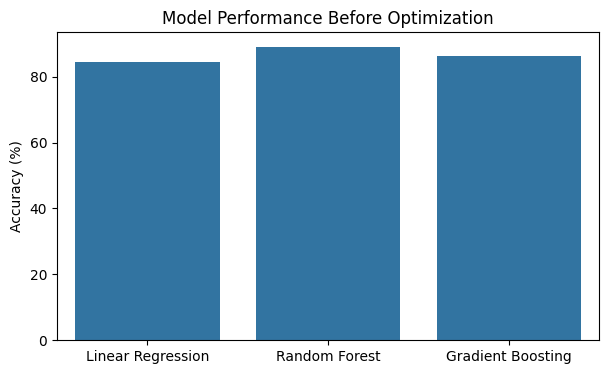

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred) * 100

    results[name] = score

    print(f"{name} Accuracy BEFORE Optimization: {score:.2f}%")

plt.figure(figsize=(7,4))

sns.barplot(x=list(results.keys()), y=list(results.values()))

plt.title("Model Performance Before Optimization")

plt.ylabel("Accuracy (%)")

plt.show()

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(random_state=42)

cv_scores = cross_val_score(rf, X_scaled, y, cv=kf, scoring='r2')

print("Cross Validation Scores:", cv_scores)

print("Mean CV Accuracy:", cv_scores.mean()*100)

param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Cross Validation Scores: [0.89107479 0.86531374 0.89744315 0.88122187 0.89342766]
Mean CV Accuracy: 88.56962424985889
Best Parameters: {'max_depth': None, 'n_estimators': 300}


In [ ]:
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(100,400),
    "max_depth": randint(5,30)
}

rand_search = RandomizedSearchCV(
    RandomForestRegressor(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)

rand_search.fit(X_train, y_train)

print("Best Randomized Params:", rand_search.best_params_)

best_model = rand_search.best_estimator_

y_pred = best_model.predict(X_test)

final_score = r2_score(y_test, y_pred)*100

print("Model Accuracy AFTER Optimization:", final_score)

# Imbalanced Data Handling (Result column)

X_res, y_res = SMOTE().fit_resample(X_scaled, df["Result"])

print("After SMOTE class balance:", np.bincount(y_res))

Best Randomized Params: {'max_depth': 12, 'n_estimators': 251}
Model Accuracy AFTER Optimization: 89.09439978557745
After SMOTE class balance: [354 354]


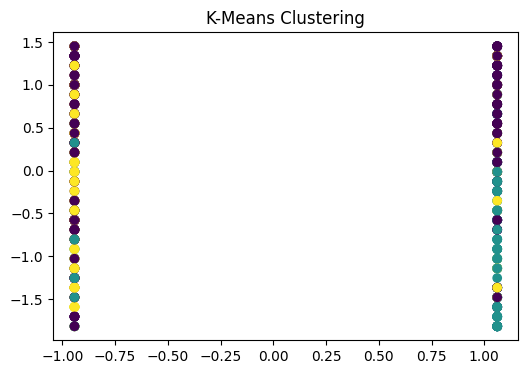

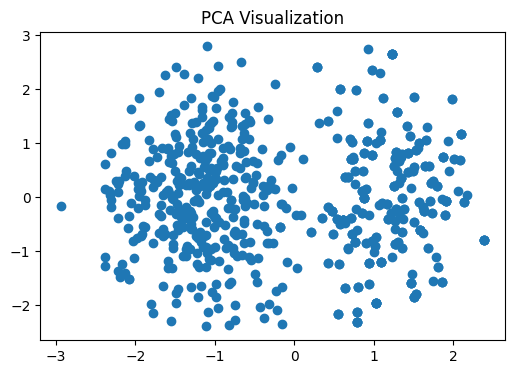

Number of anomalies detected: 35


In [ ]:
# K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6,4))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)

plt.title("K-Means Clustering")

plt.show()


# PCA (Dimensionality Reduction)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,4))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.title("PCA Visualization")

plt.show()


# Anomaly Detection

iso = IsolationForest(contamination=0.05)

outliers = iso.fit_predict(X_scaled)

print("Number of anomalies detected:", sum(outliers==-1))

In [ ]:
# ===============================
# USER INPUT PREDICTION
# ===============================

print("\nEnter Student Details")

gender = input("Gender (Male/Female): ")
age = int(input("Age: "))
study_hours = float(input("Study Hours: "))
attendance = int(input("Attendance: "))
parent_edu = input("Parent Education (High School/Bachelors/Masters/PhD): ")
internet = input("Internet Access (Yes/No): ")
activities = input("Extra Activities (Yes/No): ")

# Encoding

gender = label_encoders["Gender"].transform([gender])[0]
parent_edu = label_encoders["Parent_Education"].transform([parent_edu])[0]
internet = label_encoders["Internet_Access"].transform([internet])[0]
activities = label_encoders["Extra_Activities"].transform([activities])[0]

# Create DataFrame

user_data = pd.DataFrame([[

    gender,
    age,
    study_hours,
    attendance,
    parent_edu,
    internet,
    activities,
    1

]], columns=X.columns)

# Scaling

user_scaled = scaler.transform(user_data)

# Prediction

prediction = best_model.predict(user_scaled)

print("\nPredicted Exam Score:", round(prediction[0],2))


Enter Student Details
